In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from macrohet import visualise, colours
from tqdm.auto import tqdm
import os
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec
from tqdm import tqdm
import os
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch


from PIL import Image
plt.rcParams['font.family'] = 'Nimbus Sans'
plt.rcParams['font.size'] = 14
visualise.set_plotting_defaults()
expanded_piyg = colours.expanded_piyg
# Conversion factor
meters_per_pixel = 1.4949402023919043E-07  # Micrometers per pixel
micrometers_per_pixel = meters_per_pixel*1E6 # Micrometers per pixel

Helvetica not found. Using Nimbus Sans font.
Default plotting aesthetic loaded.


In [3]:
def replace_ytick_labels(ax, old_label, new_label):
    """
    Replace y-axis tick labels in a given matplotlib Axes object.
    
    Parameters:
    ax (matplotlib.axes.Axes): The axes on which to replace y-tick labels.
    old_label (str): The label to be replaced.
    new_label (str): The new label to replace the old label with.
    """
    # Get current y-tick labels
    yticks = ax.get_yticks()
    yticklabels = [label.get_text() for label in ax.get_yticklabels()]

    # Replace the old label with the new label
    yticklabels = [new_label if label == old_label else label for label in yticklabels]

    # Set the new y-tick labels
    ax.set_yticks(yticks)
    ax.set_yticklabels(yticklabels)

In [4]:
# df = pd.read_pickle('/Volumes/OPERA2/Nathan/macrohet_syno/results/dfs/sc_df.pkl')
df = pd.read_pickle('/mnt/SYNO/macrohet_syno/results/dfs/sc_df.pkl')


In [5]:
df

,ID,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,...,Edge Status,Uptake,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2
0,1.3.2.ND0002,0.0,0.0,0.0,4649.351562,2080.574775,NaN,False,False,107.845200,...,False,False,NaN,NaN,NaN,NaN,None,None,None,1.0
1,1.3.2.ND0002,0.5,0.0,0.0,4973.001953,2080.574775,NaN,False,False,113.264671,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
2,1.3.2.ND0002,1.0,0.0,0.0,4687.857910,2080.574775,NaN,False,False,116.562256,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
3,1.3.2.ND0002,1.5,0.0,0.0,4209.064453,2080.574775,NaN,False,False,111.890106,...,False,False,0.0,NaN,NaN,NaN,None,None,None,1.0
4,1.3.2.ND0002,2.0,0.0,0.0,4061.855225,2080.574775,False,False,False,114.113556,...,False,False,0.0,NaN,0.0,0.0,None,None,None,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1914150,9998.4.6.ND0004,59.5,0.0,NaN,261.387613,NaN,False,False,False,1034.000000,...,False,NaN,NaN,0.0,58.5,0.0,None,None,None,-1.02
1914151,9998.4.6.ND0004,60.0,0.0,NaN,275.109568,NaN,False,False,False,972.000000,...,False,NaN,NaN,0.0,59.0,0.0,None,None,None,-1.02
1914152,9998.4.6.ND0004,60.5,0.0,NaN,404.484815,NaN,False,False,False,948.000000,...,False,NaN,NaN,0.0,59.5,0.0,None,None,None,-1.02
1914153,9998.4.6.ND0004,61.0,0.0,NaN,297.055758,NaN,NaN,False,False,874.000000,...,False,NaN,NaN,0.0,NaN,NaN,None,None,None,-1.02


### Params

In [6]:
### set plotting parameters
# Input figure size in millimeters
width_mm = 280  # for example, 180 mm
height_mm = 100  # for example, 80 mm
# Convert millimeters to inches (1 inch = 25.4 mm)
width_in = width_mm / 25.4
height_in = height_mm / 25.4

### set biological parameters
# Step 1: Bin the Doubling Times into categories
bins = [0, 16, 24, float('inf')]  # Define the bins: <20, 20-24, >24
labels = ['Fast', 'Normal', 'Slow']  # Labels for each bin
# Define the desired order with CTRL at the top
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']

# Antibiotic growth

In [7]:
# Prepare the subset DataFrame, filtering for WT strain or CTRL with RD1
subset_df = df[((df['Strain'] == 'WT') | ((df['Strain'] == 'RD1') & (df['Compound'] == 'CTRL'))) 
             # & (df['r2'] >= 0.8) 
             & (df['Edge Status'] == False) 
             & (df['mtb_origin'] == 'Growth')  # are we really doing this right now? or after figure 3? 
              ].drop_duplicates(subset=['ID'])

# Continue with the usual process of exploding and filtering Doubling Times
subset_df = subset_df.explode('Doubling Times')
subset_df['Doubling Times'] = pd.to_numeric(subset_df['Doubling Times'], errors='coerce')
subset_df = subset_df[subset_df['Doubling Times'].notna()]
subset_df = subset_df[subset_df['Doubling Times'] > 0]
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)
print(f'N={len(subset_df)}')

N=728


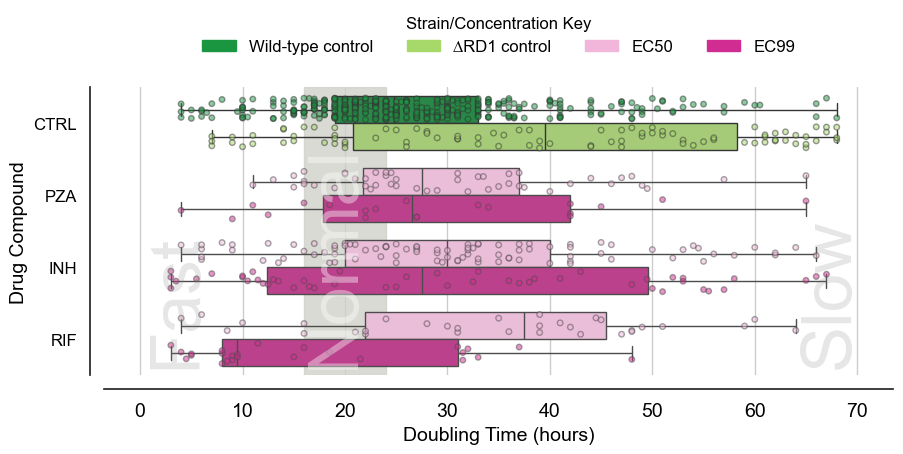

In [8]:
# Define the growth categories of the subset DataFrame
subset_df['Growth Category'] = pd.cut(subset_df['Doubling Times'], bins=bins, labels= ['Fast', 'Normal', 'Slow'], right=False)
subset_df['Mtb Strain or Drug Compound'] = subset_df.apply(
    lambda row: 'CTRL' if row['Compound'] == 'CTRL' else row['Compound'], axis=1)
subset_df['CTRL Type'] = subset_df.apply(
    lambda row: row['Strain'] if row['Compound'] == 'CTRL' else None, axis=1)

# Initialize the figure with GridSpec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[3, 1])  # Main plot and bar chart sections

# Main Plot (left side)
ax = plt.subplot(gs[0])
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    subset = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    available_concentrations = sorted(subset['Concentration'].unique())
    if compound == 'CTRL':
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type",
            whis=[0, 100], width=.75, palette=[expanded_piyg[0], expanded_piyg[1]], ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="CTRL Type", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=[expanded_piyg[0], expanded_piyg[1]], dodge=True, alpha=0.5, ax=ax, order=strain_order
        )
    else:
        palette = [expanded_piyg[4] if concentration == 'EC50' else expanded_piyg[5] for concentration in available_concentrations]
        sns.boxplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration",
            whis=[0, 100], width=.75, palette=palette, hue_order=available_concentrations, ax=ax, order=strain_order
        )
        sns.stripplot(
            data=subset, x="Doubling Times", y="Mtb Strain or Drug Compound", hue="Concentration", size=4,
            edgecolor='auto', linewidth=1, jitter=0.3,
            palette=palette, hue_order=available_concentrations, dodge=True, alpha=0.5, ax=ax, order=strain_order
        )

# Add legend and shaded regions
legend_handles = [
    mpatches.Patch(color=expanded_piyg[0], label='Wild-type control'),
    mpatches.Patch(color=expanded_piyg[1], label='∆RD1 control'),
    mpatches.Patch(color=expanded_piyg[4], label='EC50'),
    mpatches.Patch(color=expanded_piyg[5], label='EC99')
]
ax.legend(title='Strain/Concentration Key', handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4, frameon=False)
ax.axvspan(0, bins[1], color=expanded_piyg[3], alpha=0, label='Fast (<20h)')
ax.axvspan(bins[1], bins[2], color=expanded_piyg[3], alpha=0.8, label='Normal (20-28h)')
ax.axvspan(bins[2], 70, color=expanded_piyg[3], alpha=0, label='Slow (>28h)')

# Step 6: Add vertical text labels within each category region
ax.text(0+0.5, 3.2, 'Fast', fontsize=50, color='gray', alpha=0.2, ha='left', va='baseline', rotation=90)
ax.text(bins[1], 3.2, 'Normal', fontsize=50, color='white', alpha=0.4, ha='left', va='baseline', rotation=90)
ax.text(70.5, 3.2, 'Slow', fontsize=50, color='gray', alpha=0.2, ha='right', va='baseline', rotation=90)

ax.xaxis.grid(True)
replace_ytick_labels(ax, old_label='RD1', new_label='ΔRD1')

ax.set_xlabel('Doubling Time (hours)', fontsize=14)
ax.set_ylabel('Drug Compound', fontsize=14)
sns.despine(ax=ax, left=True) 
ax.tick_params(axis = 'x', left=False, labelsize = 14)

sns.despine(offset=10)

plt.tight_layout()
# plt.savefig('/mnt/SYNO/macrohet_syno/results/manuscript/f4/f4.pdf', bbox_inches='tight', dpi=314)
plt.show()


# Interactive F4

In [9]:
from dash import Dash, dcc, html, Input, Output

In [10]:
subset_df['Video Link'] = subset_df['ID'].apply(lambda ID: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{ID}_glimpse_graph.mp4")

In [11]:
scaling_factor = 1.5
vertical_offset = 0.31
# Colors for the plot
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']  # Custom color palette
colors = {
    'WT': expanded_piyg[0],
    'RD1': expanded_piyg[1],
    'EC50': expanded_piyg[-2],
    'EC99': expanded_piyg[-1],
    'Fast': 'white',#'rgba(0, 128, 0, 0.2)',
    'Normal': expanded_piyg[3], #'rgba(255, 255, 0, 0.4)',
    'Slow': 'white',#'rgba(255, 0, 0, 0.2)',
}
# Define the strain order and color palette
strain_order = ['CTRL', 'PZA', 'INH', 'RIF']  # Define the order of compounds
# reverse the order and create cat mappin
categories = subset_df['Mtb Strain or Drug Compound'].unique()[::-1]
# Update category mapping to include scaling factor
category_mapping = {category: i * scaling_factor for i, category in enumerate(categories)}

# Define vertical offsets for concentrations and CTRL types
vertical_offsets = {
    'EC50': vertical_offset,    # Shift EC50 up
    'EC99': -vertical_offset,   # Shift EC99 down
    'WT': vertical_offset,      # Shift WT slightly up
    'RD1': -vertical_offset     # Shift RD1 slightly down
}

# Legend entries configuration
legend_entries = [
    {"color": colors['WT'], "name": "Wild-type control"},
    {"color": colors['RD1'], "name": "ΔRD1 control"},
    {"color": colors['EC50'], "name": "EC50"},
    {"color": colors['EC99'], "name": "EC99"}
]


In [20]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import numpy as np

# Initialize the Dash app
app = Dash(__name__)


# Create the Plotly figure
fig = go.Figure()

# Add shaded regions
fig.add_shape(type="rect", xref="x", yref="paper", x0=0, x1=bins[1], y0=0, y1=1, fillcolor=colors['Fast'], opacity=0.4, layer="below", line_width=0)
fig.add_shape(type="rect", xref="x", yref="paper", x0=bins[1], x1=bins[2], y0=0, y1=1, fillcolor=colors['Normal'], opacity=0.4, layer="below", line_width=0)
fig.add_shape(type="rect", xref="x", yref="paper", x0=bins[2], x1=70, y0=0, y1=1, fillcolor=colors['Slow'], opacity=0.4, layer="below", line_width=0)

# Add annotations for categories
fig.add_annotation(text="Fast", x=0, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Normal", x=bins[1], y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(255, 255, 255, 0.2)", family="Helvetica"), xanchor="left", yanchor="bottom")
fig.add_annotation(text="Slow", x=70, y=-0.85, textangle=270, showarrow=False, font=dict(size=65, color="rgba(0, 0, 0, 0.2)", family="Helvetica"), xanchor="right", yanchor="bottom")

# Add boxplots and scatter points with jitter
for compound in ['CTRL', 'PZA', 'INH', 'RIF']:
    compound_data = subset_df[subset_df['Mtb Strain or Drug Compound'] == compound]
    concentrations = compound_data['Concentration'].unique()
    ctrl_types = compound_data['CTRL Type'].unique() if compound == 'CTRL' else [None]

    for ctrl_type in ctrl_types:
        ctrl_type_data = compound_data[compound_data['CTRL Type'] == ctrl_type] if ctrl_type else compound_data

        for concentration in concentrations:
            data = ctrl_type_data[ctrl_type_data['Concentration'] == concentration]

            if data.empty:
                continue

            # Define the color for the box and scatter points
            if compound == 'CTRL':
                color = colors.get(ctrl_type, 'gray')
            else:
                color = colors.get(concentration, 'gray')

            # Base numeric position for the compound
            base_y_position = category_mapping[compound]

            # Apply offsets
            y_position = base_y_position + vertical_offsets.get(ctrl_type, 0) + vertical_offsets.get(concentration, 0)

            # Add jitter for scatter points
            jitter = np.random.uniform(-vertical_offset*0.8, vertical_offset*0.8, size=len(data))
            
            # Add boxplot trace
            fig.add_trace(go.Box(
                x=data['Doubling Times'],
                y=[y_position] * len(data),
                name=f"{compound} - {ctrl_type or ''} - {concentration or ''}".strip(" - "),
                marker_color=color,
                boxmean=False,
                orientation="h",
                width=0.6,
                boxpoints=False,
                showlegend=False
            ))

            # Add scatter plot trace with video links in custom data
            fig.add_trace(go.Scatter(
                x=data['Doubling Times'],
                y=[y_position + jitter[i] for i in range(len(data))],
                mode="markers",
                name=f"{compound} {ctrl_type or ''} {'' if concentration == 'EC0' else concentration or ''}".strip(),
                marker=dict(color=color, size=8, opacity=0.6, line=dict(color='gray',  # Outline color
                                                                        width=1)),  # Outline thickness,
                customdata=data['Video Link'],  # Pass video links via custom data
                hoverinfo="text",
                text=[
                    f"<b>Doubling Time:</b> {x:.2f}<br><b>Compound:</b> {compound}<br><b>CTRL Type:</b> {ctrl_type}<br><b>Concentration:</b> {concentration}<br>"
                    for x in data['Doubling Times']
                ],
                showlegend=False
            ))
# Add legend entries using a loop
for entry in legend_entries:
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(color=entry["color"], symbol="square", size=40, line=dict(color='white', width=0)),
        name=entry["name"],
    ))

# Update the y-axis
fig.update_yaxes(tickvals=[category_mapping[category] for category in categories], ticktext=categories)

# Update the layout
fig.update_layout(
        margin=dict(l=50, r=20, t=100, b=50),  # Adjust left, right, top, and bottom margins

    title=dict(
        text="Fast-growing Intracellular Mtb evades antibiotic treatment",
        font=dict(family="Helvetica", size=24, weight='bold')  # Title font set to Helvetica
    ),
    height=len(categories) * 200,
    xaxis=dict(
            title=dict(
                text="Doubling Time (hours)",  # X-axis title text
                font=dict(family="Helvetica", size=16)  # X-axis label font set to Helvetica
        ),
    gridcolor='rgba(200,200,200,0.3)',  # Gridline color
    showline=True,  # Show the bottom axis line
    linecolor="white",  # Set the axis line to white to mimic spacing
    linewidth=15,       # Make the axis line thicker (creates a "gap" effect)
    mirror=False,       # Don't mirror the axis lines
    tickmode="linear",  # Ensure linear tick marks
    dtick=10,           # Set tick interval to 10
    tickfont=dict(family="Helvetica", size=16),  # Tick mark font set to Helvetica
    layer="above traces",  # Ensure axis stays above gridlines for clarity
),
    yaxis=dict(
        title=dict(
            text="Drug Compound",  # Y-axis title text
            font=dict(family="Helvetica", size=16)  # Y-axis label font set to Helvetica
        ),
        gridcolor='rgba(200,200,200,0.3)',  # Gridline color
        showline=False,  # Remove the left axis line
        showgrid=False,   # Remove horizontal gridlines
        tickfont=dict(family="Helvetica", size=16),  # Tick mark font set to Helvetica
    ),
    hovermode="closest",
    template="plotly_white",
    font=dict(
        family="Helvetica",  # Set default font for the entire figure
        size=14  # Default size for unspecified text elements
    ),
    legend_itemclick=False,  # Disable legend item click
    legend_itemdoubleclick=False,  # Disable legend item double-click
    legend=dict(
        orientation="h",  # Stack items horizontally
        yanchor="bottom",  # Anchor the legend at the bottom
        y=1.02,  # Position it just above the plot (slightly above 1.0)
        xanchor="center",  # Center the legend horizontally
        x=0.5  # Center the legend in the middle of the plot
    )
)

fig.add_shape(
    type="line",
    x0=-0.04,  # Start at the left edge of the plot
    x1=1,  # End at the right edge of the plot (relative to paper coordinates)
    xref="paper",  # Reference paper coordinates (0 to 1 range)
    y0=-0.015,  # Slightly below the x-axis
    y1=-0.015,  # Same as y0 to make it horizontal
    yref="paper",  # Reference paper coordinates
    line=dict(
        color="black",  # Black line for the pseudo x-axis
        width=2  # Adjust the thickness of the line
    ),
)
# Dash layout
app.layout = html.Div([
    html.Div([
        dcc.Graph(
            id="interactive-plot",
            figure=fig,
            style={"width": "70%", "display": "inline-block", "vertical-align": "top"}
        ),
        html.Div(
            id="video-container",
            style={"width": "28%", "display": "inline-block", "vertical-align": "top", "text-align": "center"}
        )
    ])
])

@app.callback(
    Output("video-container", "children"),
    [Input("interactive-plot", "hoverData")]
)
def update_video_on_hover(hoverData):
    if hoverData is None:
        return html.P("Hover over a point to see the video.", style={"font-size": "18px", "color": "gray"})

    # Extract the customdata (video link) from hoverData
    try:
        video_link = hoverData["points"][0].get("customdata", None)
        if video_link:
            return html.Video(
                src=video_link,
                controls=False,
                autoPlay=True,
                style={
                    "height": "100%",  # Match the height of the container
                    "width": "auto",   # Adjust width proportionally
                    "max-height": "calc(100vh - 100px)",  # Prevent video from exceeding viewport height
                    "border": "2px solid white",
                    "object-fit": "contain"  # Ensure the video is fully visible
                }
                )
        else:
            return html.P("No video available for this point.", style={"font-size": "18px", "color": "gray"})
    except KeyError as e:
        print(f"KeyError: {e}")
        return html.P("Hover over a point to see the video.", style={"font-size": "18px", "color": "gray"})


# Run the app
if __name__ == "__main__":
    app.run_server(debug=True, port=8055)


In [27]:
import plotly.io as pio

# Save the plot to an HTML file with added video functionality
output_file = "../interactive_plots/doubling_times.html"

html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
    <style>
        /* Set the body layout to flex */
        body {{
            display: flex;
            margin: 0;
            padding: 0;
            height: 100vh; /* Full viewport height */
        }}
        #plot {{
            width: 70%;
            height: 100%; /* Ensure the plot takes the full height */
        }}
        #video-container {{
            width: 30%;
            padding: 10px;
            text-align: center;
            align-self: flex-start; /* Align the video container at the top */
            display: flex;
            flex-direction: column;
            align-items: center;
            height: auto; /* Allow content to adjust based on video height */
            box-sizing: border-box;
        }}
        video {{
            max-height: calc(75vh - 20px); /* Constrain video height to fit viewport */
            width: auto; /* Preserve aspect ratio */
            border: 2px solid black;
            object-fit: contain; /* Ensure video fits nicely within the space */
        }}
    </style>
</head>
<body>
    <div id="plot"></div>
    <div id="video-container">
        <p>Hover over a point to see the video.</p>
    </div>
    <script>
        // Load the Plotly figure
        const figure = {fig.to_json()};

        // Render the plot
        Plotly.newPlot('plot', figure.data, figure.layout);

        // Add hover event listener
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const videoLink = point.customdata; // Extract the video link
            const videoContainer = document.getElementById('video-container');
            
            if (videoLink) {{
                // Replace content with video
                videoContainer.innerHTML = `
                    <video src="${{videoLink}}" controls autoplay></video>
                `;
            }} else {{
                // If no video, show placeholder text
                videoContainer.innerHTML = "<p>No video available for this point.</p>";
            }}
        }});
    </script>
</body>
</html>
"""

# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video functionality saved to {output_file}")


Interactive plot with video functionality saved to ../interactive_plots/doubling_times.html


# F1 interactive

In [30]:
# Filter the subset DataFrame based on conditions
IDs = df[
    (df['Compound'] == 'CTRL') &
    (df['Strain'] == 'WT') &
    (df['mtb_origin'] != 'Junk') &
    (df['Infection Status'] == True)
].ID.unique()

# Ensure that df contains only rows with IDs present in the subset_df
subset_df = df[df['ID'].isin(IDs)]

100%|███████████████████████████████████████████████████| 1154/1154 [00:10<00:00, 110.83it/s]


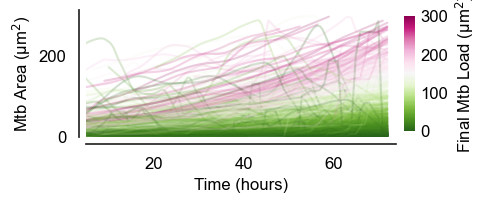

In [35]:
# Import necessary modules
from matplotlib.colors import LinearSegmentedColormap
import matplotlib as mpl

# Constants for figure size
fig_width_mm = 122.365
fig_width_inch = fig_width_mm / 25.4
fig_height_mm = 42
fig_height_inch = fig_height_mm / 25.4

# Define the colormap using 'PiYG_r'
cmap = plt.get_cmap('PiYG_r')

# Create the plot
plt.figure(figsize=(fig_width_inch, fig_height_inch))



for ID in tqdm(subset_df['ID'].unique(), total=len(subset_df['ID'].unique())):
    sc_df = subset_df[subset_df['ID'] == ID]
    time_model = sc_df['Time Model (hours)'].dropna().values
    population_model = sc_df['Mtb Area Model (µm)'].dropna().values

    # Filter based on max population value
    max_value = np.nanmax(population_model)
    if max_value < 4 or max_value > 300:
        continue

    # Calculate the color value based on the third-last value of the population model
    colour_value = population_model[-1]

    # Normalize the average value to the range [0, 1] for the colormap
    norm = mpl.colors.Normalize(vmin=0, vmax=300)
    color = cmap(norm(colour_value))

    # Plot the data with the corresponding color
    plt.plot(time_model, population_model, color=color, alpha=0.2)

# Set labels and limits
plt.xlabel('Time (hours)')
plt.ylabel('Mtb Area (µm$^2$)')
plt.ylim(bottom=0)
sns.despine(offset=5)
plt.xlim(5, 74)

# Create a wider color bar to the right of the plot
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for color bar
cbar = plt.colorbar(sm, ax=plt.gca(), orientation='vertical', pad=0.02, aspect=10, shrink=0.9)  # Adjust width with aspect and shrink
cbar.set_label('Final Mtb Load (µm$^2$)')
cbar.ax.tick_params(size=0)

# Remove the black border (outline) of the color bar
cbar.outline.set_visible(False)


### Generate single-cell snapshots from mp4s 

Need to ensure that the time frame corresponds to the correct mtb measurement

In [ ]:
# Iterate over unique IDs
for ID, ID_df in tqdm(subset_df.groupby('ID'), desc = 'iterating over cells'):
    glimpse_fn = f'/mnt/SYNO/macrohet_syno/results/glimpse_store/glimpses/{ID}.mp4'
    output_dir = f'/mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/{ID}'
    os.makedirs(output_dir, exist_ok=True)

    # Ensure the time column is sorted
    ID_df = ID_df.sort_values('Time (hours)').reset_index(drop=True)

    # Create a complete range of time values
    full_time_range = np.arange(ID_df['Time (hours)'].min(), ID_df['Time (hours)'].max() + 1)

    # Reindex the DataFrame to fill missing time values
    ID_df = ID_df.set_index('Time (hours)').reindex(full_time_range).reset_index()
    ID_df.rename(columns={'index': 'Time (hours)'}, inplace=True)

    # Open the video file
    cap = cv2.VideoCapture(glimpse_fn)
    if not cap.isOpened():
        print(f"Error: Could not open video file {glimpse_fn}")
        continue

    # Iterate over the reindexed DataFrame
    previous_frame = None  # To store the last valid frame
    video_frame_idx = 0  # Actual frame index in the video

    for i, row in ID_df.iterrows():
        frame_filename = os.path.join(output_dir, f'frame_{int(row["Time (hours)"]):03d}.png')

        if pd.isna(row['ID']):  # If the row contains NaN, use the previous frame
            print(f"Missing frame at time {row['Time (hours)']}, copying the previous frame.")
            if previous_frame is not None:
                cv2.imwrite(frame_filename, previous_frame)
        else:
            # Set the video frame position and read the frame
            cap.set(cv2.CAP_PROP_POS_FRAMES, video_frame_idx)
            ret, frame = cap.read()
            if not ret:  # Break if video reading fails
                print(f"Warning: Could not read frame {video_frame_idx} from video {glimpse_fn}")
                break

            # Save the current frame and update the previous frame
            cv2.imwrite(frame_filename, frame)
            previous_frame = frame  # Update the last valid frame

            # Increment the video frame index
            video_frame_idx += 1

    cap.release()
    print(f"Processed video for ID {ID}, frames saved to {output_dir}.")



iterating over cells:   0%|          | 0/1154 [00:00<?, ?it/s]

Missing frame at time 16.0, copying the previous frame.
Missing frame at time 41.0, copying the previous frame.
Processed video for ID 1.3.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1.3.5.PS0000.
Processed video for ID 1.6.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1.6.5.PS0000.
Processed video for ID 1007.4.3.ND0002, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1007.4.3.ND0002.
Missing frame at time 75.0, copying the previous frame.
Processed video for ID 1011.3.4.ND0002, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1011.3.4.ND0002.
Processed video for ID 1024.4.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1024.4.5.PS0000.
Processed video for ID 1027.6.5.PS0000, frames saved to /mnt/SYNO/macrohet_syno/results/glimpse_store/glimpse_frames/1027.6.5.PS0000.
Missing frame at time 25.5, copying the 

In [140]:
# add image links
subset_df['Image Link'] = subset_df['Image Link'] = subset_df.apply(
    # lambda row: f"https://s3.eu-west-2.amazonaws.com/macrohet.glimpses/{row['ID']}_t{row['Time (hours)']}.png",
    lambda row: f"https://macrohet.s3.eu-west-2.amazonaws.com/{3},{5}/glimpse_{ID}.{3}.{5}_t{row['Time (hours)']}.png",
    axis=1
)

In [138]:
subset_df.keys()

Index(['ID', 'Time (hours)', 'Mtb Area (µm)', 'dMtb Area (µm)',
       'Mphi Area (µm)', 'dMphi Area (µm)', 'Infection Status',
       'Initial Infection Status', 'Final Infection Status', 'x', 'y', 'GFP',
       'RFP', 'Eccentricity', 'MSD', 'Technical Replicate',
       'Biological Replicate', 'Strain', 'Compound', 'Concentration',
       'Cell ID', 'Acquisition ID', 'Experiment ID', 'Unique ID',
       'Edge Status', 'Uptake', 'dMtb Area between frames (µm)',
       'Mtb Area Processed (µm)', 'Time Model (hours)', 'Mtb Area Model (µm)',
       'mtb_origin', 'Doubling Amounts', 'Doubling Times', 'r2', 'Image Link'],
      dtype='object')

In [152]:
from dash import Dash, dcc, html
import plotly.graph_objects as go
import numpy as np
import pandas as pd



# Prepare data for Plotly
traces = []
cmap = plt.get_cmap('PiYG_r')
norm = mpl.colors.Normalize(vmin=0, vmax=300)

for ID in subset_df['ID'].unique():
    sc_df = subset_df[subset_df['ID'] == ID]
    time_model = sc_df['Time Model (hours)'].dropna().values - min(sc_df['Time Model (hours)'].dropna().values)
    population_model = sc_df['Mtb Area Model (µm)'].dropna().values
    compound = sc_df['Compound'].iloc[0]
    concentration = sc_df['Concentration'].iloc[0] if not 'EC0' else 'N/A'
    # Filter based on max population value
    max_value = np.nanmax(population_model)
    if max_value < 4 or max_value > 300:
        continue

    # Calculate the color value based on the final value of the population model
    colour_value = population_model[-1]
    color = f"rgba{tuple((np.array(cmap(norm(colour_value))) * 255).astype(int))}"

    # Add a trace for each line
    traces.append(go.Scatter(
        x=time_model,
        y=population_model,
        mode='lines',
        line=dict(color=color, width=2),
        name=f"ID: {ID}",  # Line name for identification (optional)
        hoverinfo="text",
        customdata=sc_df['Image Link'],  # Pass image links via custom data
        text=[f"<b>ID:</b> {ID}<br><b>Time:</b> {t:.2f} hours<br><b>Mtb Area:</b> {p:.2f} µm²"
              for t, p in zip(time_model, population_model)],
        opacity=0.6,
        showlegend=False
    ))

# Initialize Dash app
app = Dash(__name__)

# Add all traces to the figure
fig = go.Figure(data=traces + [colorbar_trace])

# colorbar
colorbar_trace = go.Scatter(
    x=[None],  # Dummy data for the color bar
    y=[None],
    mode='markers',
    marker=dict(
        size=0,
        cmax=300,
        cmin=0,
        colorbar=dict(
                    thickness=15,
                    len=0.9,  # Adjust length
                    outlinewidth=0,  # Remove black border
                    tickfont=dict(family="Helvetica", size=16)  # Colorbar tick font
        ),
        colorscale="PiYG"
    ),
    hoverinfo='none', 
    showlegend=False
)

# Add the manual title above the colorbar
colorbar_title_annotation = fig.add_annotation(
    text="Final Mtb Load (µm²)",  # Title text
    x=1.18,  # Align with the colorbar's x position
    y=0.5,  # Place above the colorbar
    xref="paper",  # Reference the paper's coordinate system for x
    yref="paper",  # Reference the paper's coordinate system for y
    showarrow=False,
    textangle=270,  # Rotate the text by 270 degrees
    font=dict(family="Helvetica", size=16),
    align="center"
)


# Ensure all lines are visible by default
fig.update_traces(visible=True)

# Update layout
fig.update_layout(
    title=dict(
        text="High-content live single-cell imaging approach<br>reveals heterogenous Mtb replication in human macrophages",
        font=dict(family="Helvetica", size=20, weight="bold")
    ),
    xaxis=dict(
        title=dict(
            text="Time (hours)",
            font=dict(family="Helvetica", size=16)
        ),
        tickfont=dict(family="Helvetica", size=16),
        gridcolor='rgba(200,200,200,0.3)',
        showline=False,
        zeroline=False,
        showgrid=False,
        range=[-4, 70],  # Add padding before and after the data range

    ),
    yaxis=dict(
        title=dict(
            text="Mtb Area (µm²)",
            font=dict(family="Helvetica", size=16)
        ),
        tickfont=dict(family="Helvetica", size=16),
        gridcolor='rgba(200,200,200,0.3)',
        showline=False,
        showgrid=False,
        zeroline=False,  # Hide the zero line
        range=[-20, 300],  # Add padding before and after the data range

    ),
    shapes=[
        # Add a pseudo y-axis line for the offset
        dict(
            type="line",
            xref="x",
            yref="y",
            x0=-2,
            x1=-2,
            y0=0,
            y1=600,
            line=dict(color="black", width=2)
        ),
        # Add a pseudo x-axis line for the offset
        dict(
            type="line",
            xref="x",
            yref="y",
            x0=0,
            x1=70,
            y0=-10,
            y1=-10,
            line=dict(color="black", width=2)
        )
    ],
    hovermode="closest",
    template="plotly_white",
    font=dict(family="Helvetica", size=16),  # General font for all labels
    margin=dict(
            l=50,  # Left margin
            r=150,  # Right margin (increased to prevent cropping)
            t=100,  # Top margin
            b=50   # Bottom margin
    )
)

# Dash layout
app.layout = html.Div([
    dcc.Graph(
        id='interactive-mtb-plot',
        figure=fig,
        style={"width": "70%", "display": "inline-block"}
    ),
    html.Div(
        id='image-container',
        style={"width": "28%", "display": "inline-block", "text-align": "center", "vertical-align": "top"}
    )
])

# Callback to display the image on hover
@app.callback(
    Output('image-container', 'children'),
    [Input('interactive-mtb-plot', 'hoverData')]
)
def display_image_on_hover(hoverData):
    if hoverData is None:
        return html.P("Hover over a point to see the corresponding image.", style={"font-size": "16px", "color": "gray"})

    # Extract the customdata (image link) from hoverData
    try:
        image_link = hoverData["points"][0].get("customdata", None)
        if image_link:
            return html.Img(src=image_link, style={"max-width": "100%", "border": "2px solid white"})
        else:
            return html.P("No image available for this point.", style={"font-size": "16px", "color": "gray"})
    except KeyError as e:
        print(f"KeyError: {e}")
        return html.P("Hover over a point to see the corresponding image.", style={"font-size": "16px", "color": "gray"})

# Run the Dash app
if __name__ == '__main__':
    app.run_server(debug=True, port=8050)

In [153]:
pio.write_html(fig, file=output_file, auto_open=False)
print(f"Saved interactive plot to {output_file}")

Saved interactive plot to ../interactive_plots/time_series.html


In [157]:
import plotly.io as pio

# Save the plot to an HTML file with added video functionality
output_file = "../interactive_plots/time_series.html"

# Create the HTML template with Plotly figure and hover functionality
html_template = f"""
<!DOCTYPE html>
<html>
<head>
    <script src="https://cdn.plot.ly/plotly-latest.min.js"></script>
</head>
<body>
    <div id="plot" style="width: 100%; height: 100vh;"></div>
    <script>
        // Load the Plotly figure
        const figure = {fig.to_json()};

        // Render the plot
        Plotly.newPlot('plot', figure.data, figure.layout);

        // Add hover event listener
        document.getElementById('plot').on('plotly_hover', function(eventData) {{
            const point = eventData.points[0];
            const imageLink = point.customdata; // Extract the image link

            if (imageLink) {{
                // Append the image to the hover tooltip
                const hoverContent = document.createElement('div');
                hoverContent.style.position = 'absolute';
                hoverContent.style.backgroundColor = 'white';
                hoverContent.style.border = '1px solid black';
                hoverContent.style.padding = '5px';
                hoverContent.style.zIndex = 1000;
                hoverContent.style.display = 'flex';
                hoverContent.style.alignItems = 'center';
                hoverContent.style.gap = '10px'; // Space between the image and text
                hoverContent.innerHTML = `
                    <img src="${{imageLink}}" style="width: 150px; height: auto; margin-right: 10px;">
                `;
                document.body.appendChild(hoverContent);

                // Position the hover content to the left of the mouse
                const hoverWidth = hoverContent.offsetWidth;
                hoverContent.style.left = `${{eventData.event.clientX - hoverWidth - 10}}px`;
                hoverContent.style.top = `${{eventData.event.clientY - 50}}px`;

                // Remove the hover content when the mouse leaves
                document.getElementById('plot').on('plotly_unhover', function() {{
                    hoverContent.remove();
                }});
            }}
        }});
    </script>
</body>
</html>
"""
# Write the HTML file
with open(output_file, "w") as f:
    f.write(html_template)

print(f"Interactive plot with video functionality saved to {output_file}")


Interactive plot with video functionality saved to ../interactive_plots/time_series.html


### the rest of F1